In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

plt.style.use("seaborn-v0_8")
torch.manual_seed(42)


In [15]:
df = pd.read_csv('data\ec2_cpu_utilization_24ae8d.csv', parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()


,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


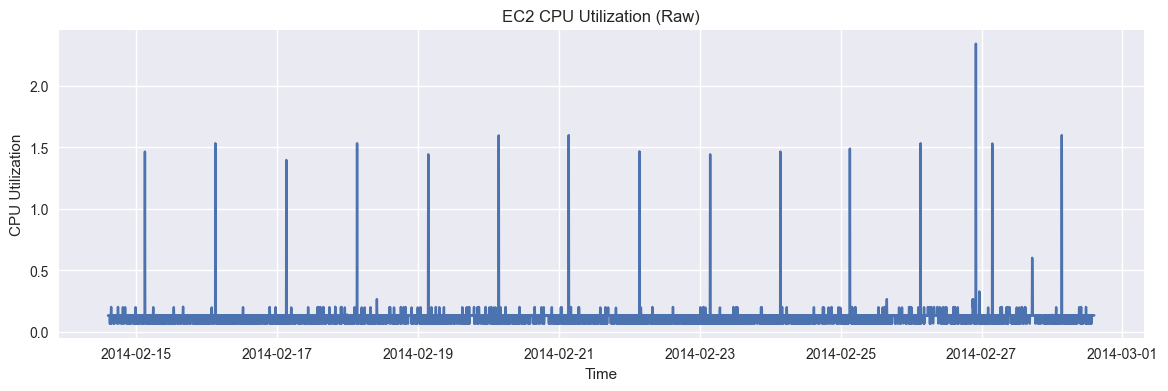

In [16]:
plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["value"])
plt.title("EC2 CPU Utilization (Raw)")
plt.xlabel("Time")
plt.ylabel("CPU Utilization")
plt.show()


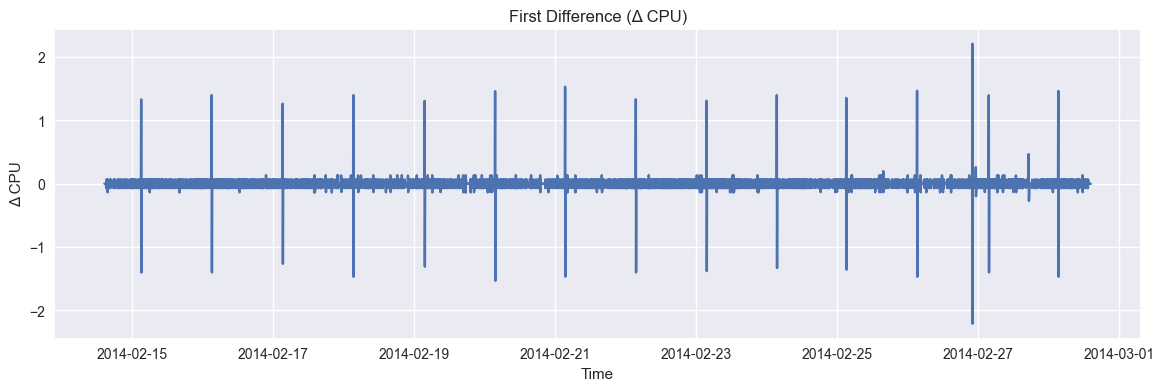

In [17]:
df["diff"] = df["value"].diff()

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["diff"])
plt.title("First Difference (Δ CPU)")
plt.xlabel("Time")
plt.ylabel("Δ CPU")
plt.show()


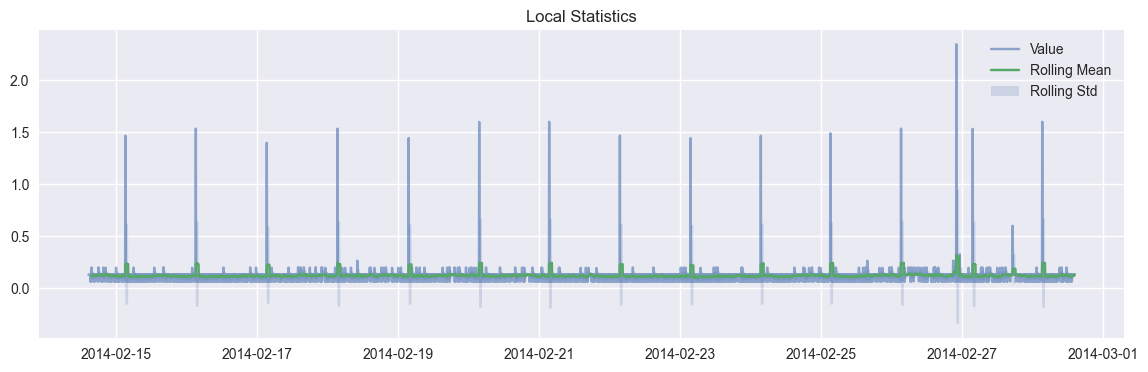

In [18]:
window = 12  # 1 hour

df["rolling_mean"] = df["value"].rolling(window).mean()
df["rolling_std"] = df["value"].rolling(window).std()

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["value"], alpha=0.6, label="Value")
plt.plot(df["timestamp"], df["rolling_mean"], label="Rolling Mean")
plt.fill_between(
    df["timestamp"],
    df["rolling_mean"] - df["rolling_std"],
    df["rolling_mean"] + df["rolling_std"],
    alpha=0.2,
    label="Rolling Std"
)
plt.legend()
plt.title("Local Statistics")
plt.show()


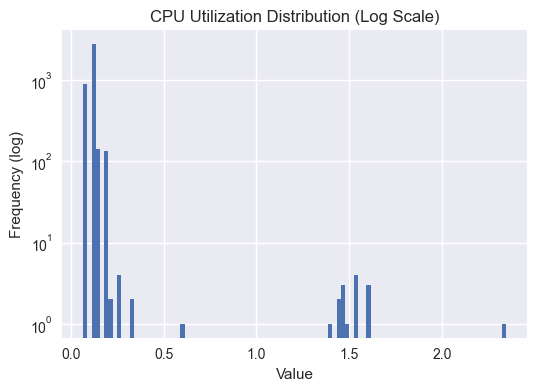

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(df["value"], bins=100, log=True)
plt.title("CPU Utilization Distribution (Log Scale)")
plt.xlabel("Value")
plt.ylabel("Frequency (log)")
plt.show()


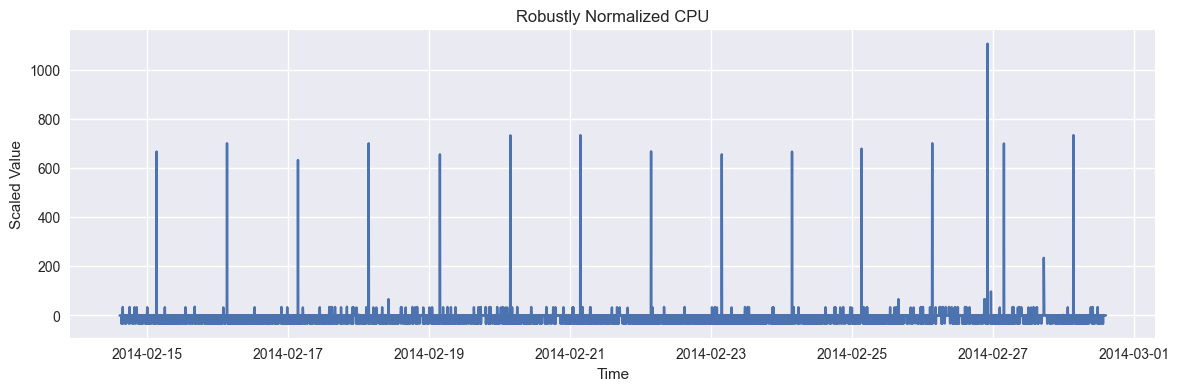

In [20]:
scaler = RobustScaler()
df["value_scaled"] = scaler.fit_transform(df[["value"]])

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["value_scaled"])
plt.title("Robustly Normalized CPU")
plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.show()


In [21]:
L = 60   # past window (5 hours)
H = 3   # future window (1 hour)

values = df["value_scaled"].values

X, Y = [], []

for i in range(L, len(values) - H):
    X.append(values[i-L:i])
    Y.append(values[i:i+H])

X = np.array(X)
Y = np.array(Y)

print("Input shape:", X.shape)
print("Target shape:", Y.shape)


Input shape: (3969, 60)
Target shape: (3969, 3)


In [22]:
split_idx = int(0.7 * len(X))

X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]


In [23]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


In [24]:
train_loader = DataLoader(
    TimeSeriesDataset(X_train, Y_train),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TimeSeriesDataset(X_test, Y_test),
    batch_size=64,
    shuffle=False
)


In [25]:
class GRUForecast(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, H)

    def forward(self, x):
        x = x.unsqueeze(-1)  # (B, L, 1)
        _, h = self.gru(x)
        return self.fc(h.squeeze(0))


In [26]:
loss_history = []

model = GRUForecast()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.SmoothL1Loss(beta=1.0)

epochs = 1001

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    loss_history.append(avg_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.6f}")


Epoch 1/1001 - Avg Loss: 11.291903
Epoch 51/1001 - Avg Loss: 10.963478
Epoch 101/1001 - Avg Loss: 10.422313
Epoch 151/1001 - Avg Loss: 9.930399
Epoch 201/1001 - Avg Loss: 9.230121
Epoch 251/1001 - Avg Loss: 9.148752
Epoch 301/1001 - Avg Loss: 10.295045
Epoch 351/1001 - Avg Loss: 8.563767
Epoch 401/1001 - Avg Loss: 8.928657
Epoch 451/1001 - Avg Loss: 8.468019
Epoch 501/1001 - Avg Loss: 8.424473
Epoch 551/1001 - Avg Loss: 8.232908
Epoch 601/1001 - Avg Loss: 7.626590
Epoch 651/1001 - Avg Loss: 8.898350
Epoch 701/1001 - Avg Loss: 8.797048
Epoch 751/1001 - Avg Loss: 8.102936
Epoch 801/1001 - Avg Loss: 8.096589
Epoch 851/1001 - Avg Loss: 7.685415
Epoch 901/1001 - Avg Loss: 8.110826
Epoch 951/1001 - Avg Loss: 7.856638
Epoch 1001/1001 - Avg Loss: 7.771800


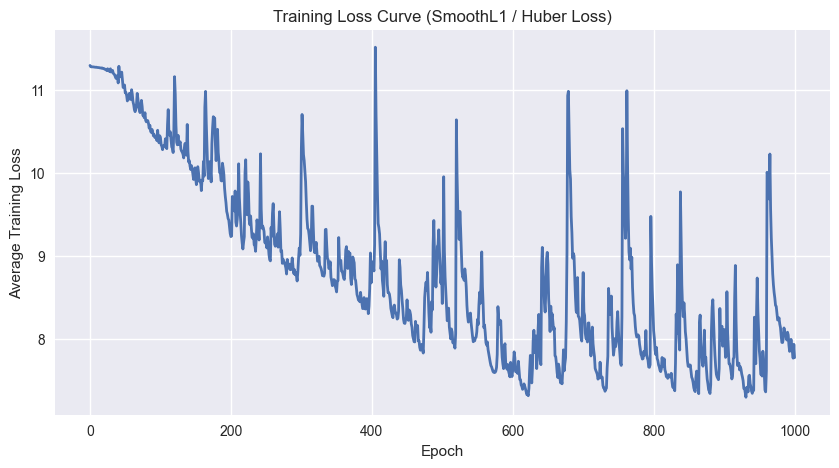

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss Curve (SmoothL1 / Huber Loss)")
plt.grid(True)
plt.show()


In [28]:
model.eval()

with torch.no_grad():
    sample_x = torch.tensor(
        X_test[100],
        dtype=torch.float32
    ).unsqueeze(0)

    sample_y = Y_test[100]

    pred = model(sample_x).squeeze().numpy()


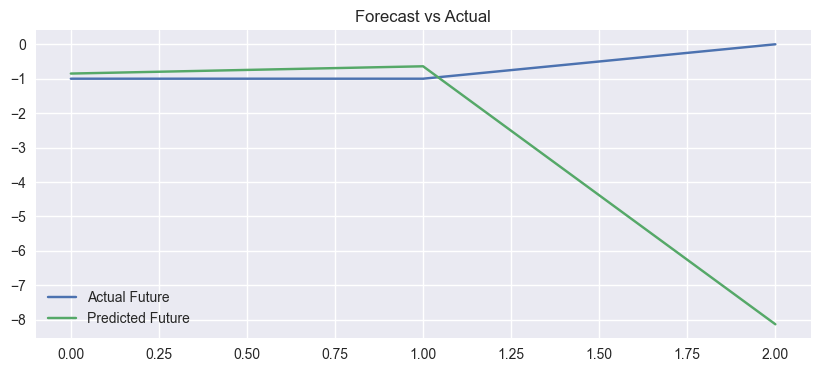

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(sample_y, label="Actual Future")
plt.plot(pred, label="Predicted Future")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [30]:
errors = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        err = torch.mean(torch.abs(preds - yb), dim=1)
        errors.extend(err.numpy())

errors = np.array(errors)


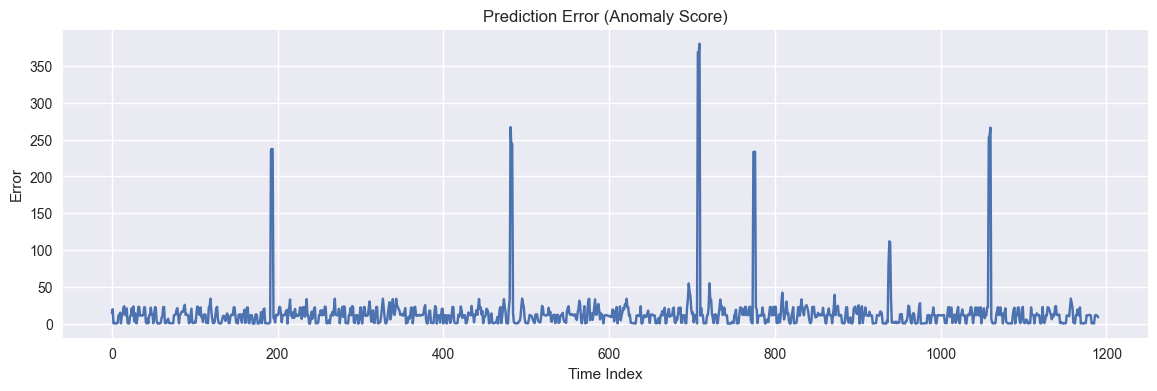

In [31]:
plt.figure(figsize=(14, 4))
plt.plot(errors)
plt.title("Prediction Error (Anomaly Score)")
plt.xlabel("Time Index")
plt.ylabel("Error")
plt.show()


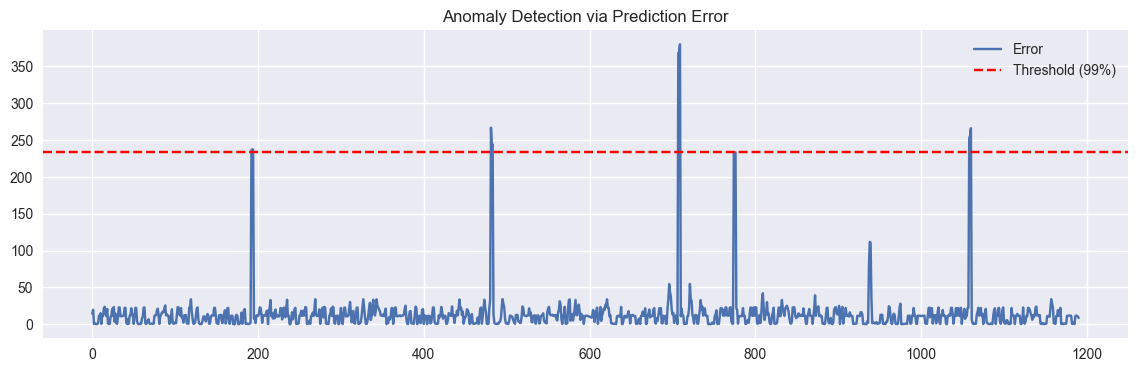

In [32]:
threshold = np.percentile(errors, 99)

plt.figure(figsize=(14, 4))
plt.plot(errors, label="Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold (99%)")
plt.legend()
plt.title("Anomaly Detection via Prediction Error")
plt.show()
